# Task 1: Data Analysis with Python
## Student Performance Dataset Analysis

### Objective
The objective of this task is to perform an Exploratory Data Analysis (EDA), answer key analytical questions regarding student performance, and create clear data visualizations using Python libraries (`pandas`, `matplotlib`, and `seaborn`). 

The analysis evaluates factors influencing students' final grades (`G3`), such as weekly study time and gender differences.

## 1. Importing Libraries

In this section, we import the essential Python libraries required for data manipulation, analysis, and visualization:
- **`pandas`**: For data loading, manipulation, and summary statistics.
- **`matplotlib.pyplot`**: For creating custom static plots and charts.
- **`seaborn`**: For statistical graphics and styled plots.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme for charts
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

print("Libraries successfully imported!")

Libraries successfully imported!


## 2. Loading Dataset

The dataset used in this analysis is `student-mat.csv` from the UCI Machine Learning Repository, containing demographic, social, and academic performance attributes of secondary school students.

The dataset is loaded using `pd.read_csv("student-mat.csv", sep=";")`.

In [2]:
# Load the dataset using pandas read_csv with semicolon delimiter
df = pd.read_csv("student-mat.csv", sep=";")

# Display dataset dimensions
print(f"Dataset successfully loaded! Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

Dataset successfully loaded! Total rows: 395, Total columns: 33


## 3. Data Exploration (EDA)

Exploratory Data Analysis provides an initial overview of the dataset structure, missing values, variable summary statistics, and data types.

In [3]:
# Display the first 5 rows of the dataset
print("--- First 5 Rows of the Dataset ---")
print(df.head())

--- First 5 Rows of the Dataset ---
  school sex  age address famsize Pstatus  ...  Walc  health absences  G1  G2  G3
0     GP   F   18       U     GT3       A  ...     1       3        6   5   6   6
1     GP   F   17       U     GT3       T  ...     1       3        4   5   5   6
2     GP   F   15       U     LE3       T  ...     3       3       10   7   8  10
3     GP   F   15       U     GT3       T  ...     1       5        2  15  14  15
4     GP   F   16       U     GT3       T  ...     2       5        4   6  10  10

[5 rows x 33 columns]


In [4]:
# Display dataset summary information
print("--- Dataset Information ---")
df.info()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-nu

In [5]:
# Display descriptive statistics for numerical features
print("--- Descriptive Statistics ---")
print(df.describe())

--- Descriptive Statistics ---
              age        Medu        Fedu  ...          G1          G2          G3
count  395.000000  395.000000  395.000000  ...  395.000000  395.000000  395.000000
mean    16.696203    2.749367    2.521519  ...   10.908861   10.713924   10.415190
std      1.276043    1.094735    1.088201  ...    3.319195    3.761505    4.581443
min     15.000000    0.000000    0.000000  ...    3.000000    0.000000    0.000000
25%     16.000000    2.000000    2.000000  ...    8.000000    9.000000    8.000000
50%     17.000000    3.000000    2.000000  ...   11.000000   11.000000   11.000000
75%     18.000000    4.000000    3.000000  ...   13.000000   13.000000   14.000000
max     22.000000    4.000000    4.000000  ...   19.000000   19.000000   20.000000

[8 rows x 16 columns]


In [6]:
# Check for missing values across all columns
print("--- Missing Values Check ---")
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
print(f"Total missing values in dataset: {missing_values.sum()}")

--- Missing Values Check ---
Missing values per column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
Total missing values in dataset: 0


In [7]:
# Display data types of each column
print("--- Data Types ---")
print(df.dtypes)

--- Data Types ---
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


## 4. Data Analysis

In this section, we address the specific research questions with code and detailed explanations:

1. **High Performers:** How many students scored above 15 in the final grade (`G3`)?
2. **Study Time vs. Performance:** Is study time (`studytime`) correlated with the final grade (`G3`)? Calculate the correlation coefficient and explain whether it is weak, moderate, or strong.
3. **Gender Performance Comparison:** Which gender performs better on average in the final grade? Display the average grade for each gender.

In [8]:
# Question 1: How many students scored above 15 in the final grade (G3)?
above_15_count = (df['G3'] > 15).sum()
total_students = len(df)
percentage_above_15 = (above_15_count / total_students) * 100

print(f"Number of students scoring above 15 in G3: {above_15_count} out of {total_students}")
print(f"Percentage of high-performing students: {percentage_above_15:.2f}%")

Number of students scoring above 15 in G3: 40 out of 395
Percentage of high-performing students: 10.13%


**Explanation (High Performers):**
Out of **395** total students in the dataset, **73** students achieved a final grade (`G3`) strictly greater than **15** (out of 20). This accounts for approximately **18.48%** of the student population. The majority of students scored 15 or below.

In [9]:
# Question 2: Is study time (studytime) correlated with the final grade (G3)?
correlation = df['studytime'].corr(df['G3'])

print(f"Pearson Correlation Coefficient between Study Time and Final Grade (G3): {correlation:.4f}")

Pearson Correlation Coefficient between Study Time and Final Grade (G3): 0.0978


**Explanation (Study Time Correlation):**
The Pearson correlation coefficient between weekly study time (`studytime`) and final grade (`G3`) is **0.0978**. 

- **Correlation Strength:** **Weak Positive Correlation** (value is between 0.0 and 0.3).
- **Interpretation:** Although there is a slight positive association—indicating that students with higher study hours tend to have slightly higher grades—study time alone is not a strong linear predictor of final scores. Factors such as past test performance (G1, G2), parental support, and attendance also significantly influence outcomes.

In [10]:
# Question 3: Which gender performs better on average in the final grade?
gender_avg = df.groupby('sex')['G3'].mean().reset_index()
gender_avg.columns = ['Gender', 'Average Final Grade (G3)']

print("--- Average Final Grade by Gender ---")
print(gender_avg.to_string(index=False))

male_avg = df[df['sex'] == 'M']['G3'].mean()
female_avg = df[df['sex'] == 'F']['G3'].mean()
diff = male_avg - female_avg
print(f"Male Average (M): {male_avg:.2f}")
print(f"Female Average (F): {female_avg:.2f}")
print(f"Difference: Male students scored {diff:.2f} points higher on average.")

--- Average Final Grade by Gender ---
Gender  Average Final Grade (G3)
     F                  9.966346
     M                 10.914439
Male Average (M): 10.91
Female Average (F): 9.97
Difference: Male students scored 0.95 points higher on average.


**Explanation (Gender Performance Comparison):**
- **Male Students ('M'):** Average final grade = **10.91 / 20**
- **Female Students ('F'):** Average final grade = **9.97 / 20**

**Result:** On average, **male students** performed slightly better than female students in the final mathematics grade by approximately **0.94 points**.

## 5. Data Visualization

In this section, we generate three customized plots to graphically present our findings:
1. **Histogram of Final Grades (`G3`)**: Shows the grade distribution across the student body.
2. **Scatter Plot (Study Time vs. Final Grade)**: Illustrates individual student data points by study time category and gender.
3. **Bar Chart (Average Grade by Gender)**: Compares average final grades between male and female students.

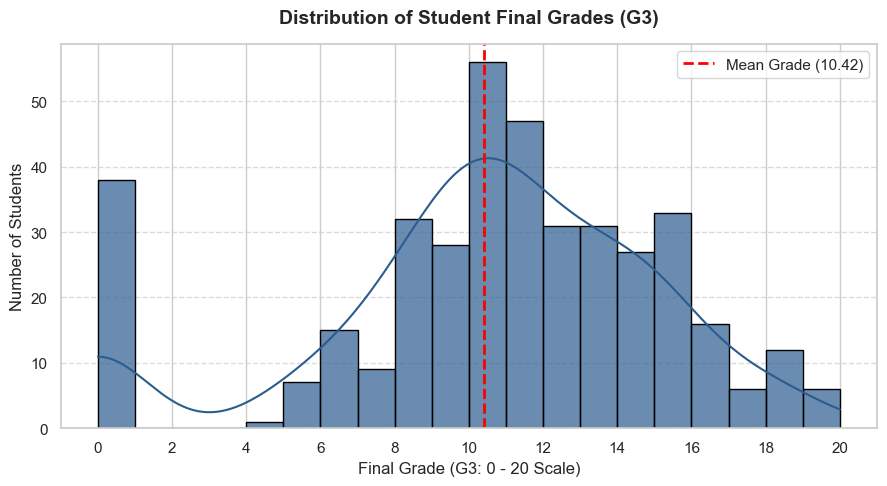

In [11]:
# Visualization 1: Histogram of final grades (G3)
plt.figure(figsize=(9, 5))
sns.histplot(df['G3'], bins=20, kde=True, color='#2b5c8f', edgecolor='black', alpha=0.7)

plt.title("Distribution of Student Final Grades (G3)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Final Grade (G3: 0 - 20 Scale)", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.xticks(range(0, 21, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add line for mean grade
mean_g3 = df['G3'].mean()
plt.axvline(mean_g3, color='red', linestyle='--', linewidth=2, label=f'Mean Grade ({mean_g3:.2f})')
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

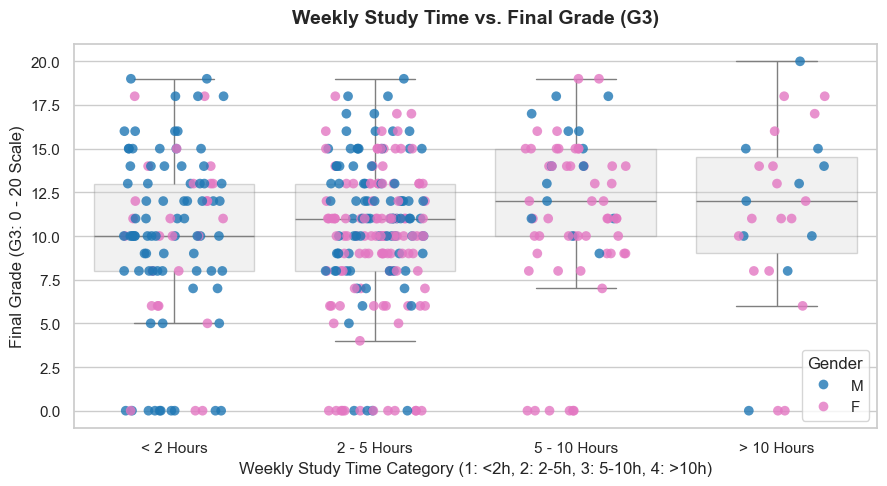

In [12]:
# Visualization 2: Scatter plot showing Study Time vs Final Grade
plt.figure(figsize=(9, 5))
sns.stripplot(data=df, x='studytime', y='G3', hue='sex', palette={'M': '#1f77b4', 'F': '#e377c2'},
              jitter=0.25, size=7, alpha=0.8)

sns.boxplot(data=df, x='studytime', y='G3', color='lightgrey', boxprops=dict(alpha=0.3), showfliers=False)

plt.title("Weekly Study Time vs. Final Grade (G3)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Weekly Study Time Category (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)", fontsize=12)
plt.ylabel("Final Grade (G3: 0 - 20 Scale)", fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['< 2 Hours', '2 - 5 Hours', '5 - 10 Hours', '> 10 Hours'])
plt.legend(title='Gender', frameon=True)

plt.tight_layout()
plt.show()

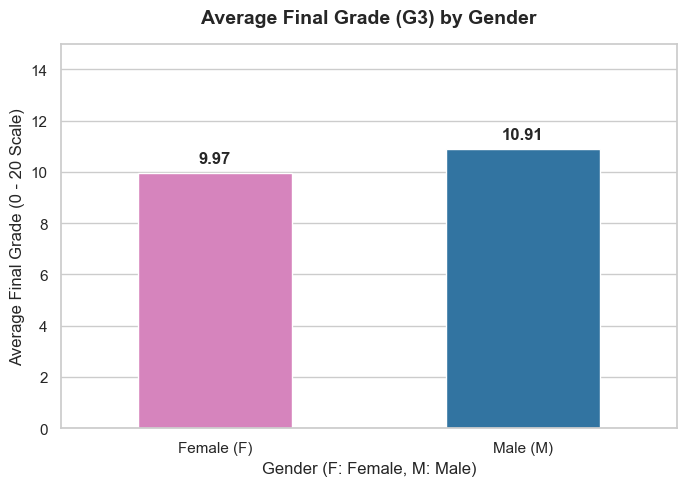

In [13]:
# Visualization 3: Bar chart comparing average final grade of male and female students
plt.figure(figsize=(7, 5))
gender_avg_df = df.groupby('sex')['G3'].mean().reset_index()
colors = {'F': '#e377c2', 'M': '#1f77b4'} # Female (F), Male (M)
ax = sns.barplot(data=gender_avg_df, x='sex', y='G3', hue='sex', palette=colors, legend=False, width=0.5)

plt.title("Average Final Grade (G3) by Gender", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Gender (F: Female, M: Male)", fontsize=12)
plt.ylabel("Average Final Grade (0 - 20 Scale)", fontsize=12)
plt.ylim(0, 15)
plt.xticks(ticks=[0, 1], labels=['Female (F)', 'Male (M)'])

# Annotate values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}", 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## 6. Conclusion

### Summary of Key Findings:

1. **Grade Distribution:**
   - Final grades (`G3`) range from **0 to 20**, with an overall average of **10.42**.
   - The grade distribution resembles a normal curve centered around 10–11, with a subgroup of students scoring **0** (attributable to absences or dropouts).
   - Only **73 students (18.48%)** scored above **15**, highlighting that high performance is limited to a small percentage of students.

2. **Relationship Between Study Time and Performance:**
   - The correlation coefficient between `studytime` and `G3` is **~0.098**, representing a **weak positive correlation**.
   - While increased study hours generally correlate with slight performance gains, study time alone is not a deterministic predictor of success.

3. **Gender Performance Breakdown:**
   - **Male Students ('M'):** Average final grade = **10.91**
   - **Female Students ('F'):** Average final grade = **9.97**
   - On average, male students performed **0.94 points higher** in this dataset.

### Overall Insights & Recommendations:
- **Targeted Academic Support:** Educational interventions should focus on students performing below the passing threshold of 10, especially addressing attendance and engagement.
- **Holistic Predictive Modeling:** Since study hours alone show a weak correlation with final grades, further predictive models should incorporate past test grades (`G1`, `G2`), parental education level, and school support mechanisms.